In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhrajaiswal/emotions-detection-text-dataset/emotions.txt


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/abhrajaiswal/emotions-detection-text-dataset/emotions.txt',
    sep=';'
)

df.head()

,i didnt feel humiliated,sadness
0,i can go from feeling so hopeless to so damned...,sadness
1,im grabbing a minute to post i feel greedy wrong,anger
2,i am ever feeling nostalgic about the fireplac...,love
3,i am feeling grouchy,anger
4,ive been feeling a little burdened lately wasn...,sadness


In [5]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/abhrajaiswal/emotions-detection-text-dataset/emotions.txt',
    sep=';',
    header=None,
    names=['text', 'emotion']
)

df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nEmotion Classes:")
print(df['emotion'].unique())

print("\nNumber of Classes:")
print(df['emotion'].nunique())

print("\nClass Distribution:")
print(df['emotion'].value_counts())

df.head()

Shape: (16000, 2)

Columns:
Index(['text', 'emotion'], dtype='object')

Data Types:
text       object
emotion    object
dtype: object

Missing Values:
text       0
emotion    0
dtype: int64

Duplicate Rows:
1

Emotion Classes:
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Number of Classes:
6

Class Distribution:
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
class_distribution = df['emotion'].value_counts()

class_percentage = df['emotion'].value_counts(normalize=True) * 100

print(class_percentage)

emotion
joy         33.51250
sadness     29.16250
anger       13.49375
fear        12.10625
love         8.15000
surprise     3.57500
Name: proportion, dtype: float64


In [8]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

In [9]:
df[['text', 'word_count']].head()

,text,word_count
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,21
2,im grabbing a minute to post i feel greedy wrong,10
3,i am ever feeling nostalgic about the fireplac...,18
4,i am feeling grouchy,4


In [10]:
df['word_count'].describe()

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: word_count, dtype: float64

In [11]:
df.nlargest(10, 'word_count')[['text', 'emotion', 'word_count']]

,text,emotion,word_count
6322,i guess which meant or so i assume no photos n...,sadness,66
46,i lost my special mind but don t worry i m sti...,joy,64
7222,i am happier this year in all ways i am just g...,joy,64
9618,i feel you i dont believ in you but i keep my ...,joy,64
9626,i feel in my bones like nobody cares if im her...,sadness,64
11220,i confused my feelings with the truth because ...,love,63
1542,i feel tat all of us in this world are clever ...,joy,62
5373,i feel not offended in any form and should not...,anger,62
10390,i hope that those of you who actauly found thi...,joy,62
14177,i like to add a slice of cheese and some peppe...,love,62


In [12]:
df.groupby('emotion')['word_count'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

,count,mean,median,min,max
emotion,,,,,
love,1304,20.700153,19.0,3,63
surprise,572,19.970280,18.0,3,60
joy,5362,19.498135,18.0,2,64
anger,2159,19.229736,17.0,2,62
fear,1937,18.844605,17.0,2,60
sadness,4666,18.361980,16.0,2,66


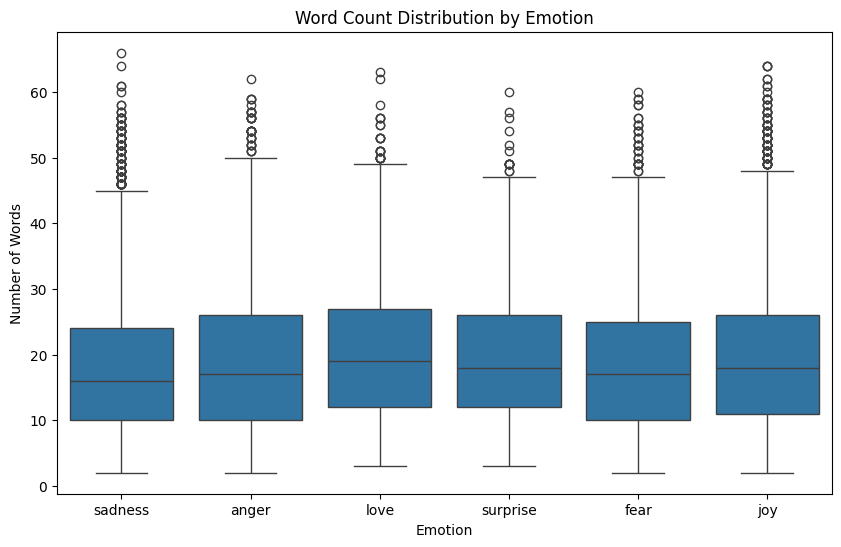

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='emotion',
    y='word_count'
)

plt.title('Word Count Distribution by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of Words')

plt.show()

In [14]:
from collections import Counter

all_words = ' '.join(df['text']).lower().split()

word_counts = Counter(all_words)

word_counts.most_common(20)

[('i', 25859),
 ('feel', 11183),
 ('and', 9589),
 ('to', 8972),
 ('the', 8370),
 ('a', 6200),
 ('feeling', 5112),
 ('that', 5112),
 ('of', 4990),
 ('my', 4283),
 ('in', 3433),
 ('it', 3127),
 ('like', 2908),
 ('so', 2527),
 ('for', 2431),
 ('im', 2430),
 ('me', 2309),
 ('but', 2255),
 ('was', 2227),
 ('have', 2224)]

In [15]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
words = [
    word
    for word in all_words
    if word not in stop_words
]

In [17]:
word_counts = Counter(words)

word_counts.most_common(30)

[('feel', 11183),
 ('feeling', 5112),
 ('like', 2908),
 ('im', 2430),
 ('really', 942),
 ('know', 853),
 ('time', 794),
 ('get', 740),
 ('little', 736),
 ('people', 654),
 ('would', 646),
 ('want', 644),
 ('think', 596),
 ('one', 596),
 ('still', 595),
 ('ive', 587),
 ('even', 568),
 ('life', 551),
 ('make', 523),
 ('bit', 516),
 ('something', 513),
 ('love', 500),
 ('much', 496),
 ('going', 487),
 ('dont', 482),
 ('things', 480),
 ('way', 470),
 ('could', 453),
 ('day', 428),
 ('back', 403)]

In [18]:
from collections import Counter

for emotion in df['emotion'].unique():

    emotion_text = ' '.join(
        df[df['emotion'] == emotion]['text']
    ).lower().split()

    emotion_words = [
        word for word in emotion_text
        if word not in stop_words
    ]

    counts = Counter(emotion_words)

    print(f"\n===== {emotion.upper()} =====")
    print(counts.most_common(15))


===== SADNESS =====
[('feel', 3299), ('feeling', 1523), ('like', 864), ('im', 683), ('really', 276), ('know', 275), ('get', 225), ('ive', 217), ('would', 203), ('still', 200), ('time', 199), ('little', 194), ('even', 186), ('want', 179), ('people', 176)]

===== ANGER =====
[('feel', 1459), ('feeling', 721), ('like', 384), ('im', 342), ('really', 124), ('get', 121), ('time', 118), ('know', 115), ('little', 105), ('people', 105), ('want', 98), ('even', 95), ('would', 89), ('angry', 85), ('way', 85)]

===== LOVE =====
[('feel', 929), ('feeling', 378), ('like', 306), ('im', 193), ('love', 97), ('really', 92), ('know', 79), ('sweet', 69), ('loving', 68), ('time', 68), ('want', 65), ('one', 64), ('passionate', 63), ('caring', 62), ('life', 56)]

===== SURPRISE =====
[('feel', 356), ('feeling', 209), ('im', 91), ('like', 90), ('amazed', 67), ('impressed', 61), ('overwhelmed', 58), ('weird', 57), ('surprised', 55), ('curious', 54), ('funny', 49), ('strange', 45), ('shocked', 45), ('little', 4

In [19]:
for emotion in df['emotion'].unique():

    emotion_df = df[df['emotion'] == emotion]

    emotion_words = ' '.join(emotion_df['text']).lower().split()

    emotion_words = [
        word for word in emotion_words
        if word not in stop_words
    ]

    counts = Counter(emotion_words)

    total_words = len(emotion_words)

    print(f"\n===== {emotion.upper()} =====")

    for word, count in counts.most_common(15):
        percentage = (count / total_words) * 100
        print(f"{word}: {count} ({percentage:.2f}%)")


===== SADNESS =====
feel: 3299 (7.83%)
feeling: 1523 (3.61%)
like: 864 (2.05%)
im: 683 (1.62%)
really: 276 (0.66%)
know: 275 (0.65%)
get: 225 (0.53%)
ive: 217 (0.51%)
would: 203 (0.48%)
still: 200 (0.47%)
time: 199 (0.47%)
little: 194 (0.46%)
even: 186 (0.44%)
want: 179 (0.42%)
people: 176 (0.42%)

===== ANGER =====
feel: 1459 (7.25%)
feeling: 721 (3.58%)
like: 384 (1.91%)
im: 342 (1.70%)
really: 124 (0.62%)
get: 121 (0.60%)
time: 118 (0.59%)
know: 115 (0.57%)
little: 105 (0.52%)
people: 105 (0.52%)
want: 98 (0.49%)
even: 95 (0.47%)
would: 89 (0.44%)
angry: 85 (0.42%)
way: 85 (0.42%)

===== LOVE =====
feel: 929 (7.17%)
feeling: 378 (2.92%)
like: 306 (2.36%)
im: 193 (1.49%)
love: 97 (0.75%)
really: 92 (0.71%)
know: 79 (0.61%)
sweet: 69 (0.53%)
loving: 68 (0.52%)
time: 68 (0.52%)
want: 65 (0.50%)
one: 64 (0.49%)
passionate: 63 (0.49%)
caring: 62 (0.48%)
life: 56 (0.43%)

===== SURPRISE =====
feel: 356 (6.39%)
feeling: 209 (3.75%)
im: 91 (1.63%)
like: 90 (1.62%)
amazed: 67 (1.20%)
impres

In [20]:
common_words = {
    'feel',
    'feeling',
    'like',
    'im',
    'really',
    'know',
    'get',
    'time',
    'want',
    'would',
    'people',
    'still',
    'one',
    'something',
    'think',
    'little',
    'even',
    'ive',
    'make',
    'life',
    'way',
    'bit'
}

for emotion in df['emotion'].unique():

    emotion_text = ' '.join(
        df[df['emotion'] == emotion]['text']
    ).lower().split()

    emotion_words = [
        word for word in emotion_text
        if word not in stop_words
        and word not in common_words
    ]

    counts = Counter(emotion_words)

    print(f"\n===== {emotion.upper()} =====")
    print(counts.most_common(15))


===== SADNESS =====
[('dont', 158), ('things', 155), ('much', 152), ('day', 137), ('going', 129), ('back', 126), ('pretty', 120), ('love', 111), ('could', 110), ('right', 110), ('cant', 109), ('always', 107), ('go', 106), ('alone', 105), ('today', 104)]

===== ANGER =====
[('angry', 85), ('things', 80), ('could', 79), ('dont', 70), ('irritable', 70), ('cold', 68), ('back', 64), ('cant', 64), ('greedy', 63), ('offended', 62), ('going', 61), ('bothered', 61), ('fucked', 60), ('resentful', 60), ('selfish', 59)]

===== LOVE =====
[('love', 97), ('sweet', 69), ('loving', 68), ('passionate', 63), ('caring', 62), ('sympathetic', 55), ('hot', 55), ('lovely', 55), ('feelings', 55), ('liked', 54), ('loved', 53), ('need', 52), ('longing', 51), ('nostalgic', 48), ('blessed', 47)]

===== SURPRISE =====
[('amazed', 67), ('impressed', 61), ('overwhelmed', 58), ('weird', 57), ('surprised', 55), ('curious', 54), ('funny', 49), ('strange', 45), ('shocked', 45), ('amazing', 40), ('dazed', 32), ('much', 

**EDA Conclusion:**
The dataset contains 16,000 text samples across six emotion classes. No missing values were found, although one duplicate record exists. The dataset is noticeably imbalanced, with Joy and Sadness representing the majority of samples while Surprise is significantly underrepresented. Text samples contain an average of approximately 19 words, with lengths ranging from 2 to 66 words. Vocabulary analysis shows that generic terms such as "feel", "feeling", and "like" occur across multiple classes, while emotion-specific words such as "angry", "loving", "shocked", "terrified", and "happy" provide stronger signals for classification. Negation terms such as "dont" and "cant" are also common and should be preserved during preprocessing because they can change the meaning of a sentence.

In [21]:
import pandas as pd
import re

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv(
    '/kaggle/input/datasets/abhrajaiswal/emotions-detection-text-dataset/emotions.txt',
    sep=';',
    header=None,
    names=['text', 'emotion']
)

print("Original shape:", df.shape)


# ==========================================
# 2. REMOVE DUPLICATE ROWS
# ==========================================

df = df.drop_duplicates()


# ==========================================
# 3. REMOVE EDA-ONLY COLUMN IF IT EXISTS
# ==========================================

if 'word_count' in df.columns:
    df = df.drop(columns=['word_count'])


# ==========================================
# 4. REMOVE MISSING VALUES
# ==========================================

df = df.dropna(subset=['text', 'emotion'])


# ==========================================
# 5. REMOVE EMPTY TEXT
# ==========================================

df['text'] = df['text'].str.strip()

df = df[df['text'] != '']


# ==========================================
# 6. CONVERT TEXT TO LOWERCASE
# ==========================================

df['text'] = df['text'].str.lower()


# ==========================================
# 7. REMOVE PUNCTUATION
# ==========================================

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)


# ==========================================
# 8. RESET INDEX
# ==========================================

df = df.reset_index(drop=True)


# ==========================================
# 9. CHECK FINAL DATASET
# ==========================================

print("\nFinal shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nEmotion distribution:")
print(df['emotion'].value_counts())

print("\nFirst 5 rows:")
print(df.head())

Original shape: (16000, 2)

Final shape: (15999, 2)

Columns:
Index(['text', 'emotion'], dtype='object')

Missing values:
text       0
emotion    0
dtype: int64

Duplicates: 0

Emotion distribution:
emotion
joy         5361
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

First 5 rows:
                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 1. SEPARATE FEATURES AND TARGET
# ==========================================

X = df['text']
y = df['emotion']


# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 3. CHECK SPLIT
# ==========================================

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())


# ==========================================
# 4. CREATE TF-IDF VECTORIZER
# ==========================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)


# ==========================================
# 5. FIT TF-IDF ONLY ON TRAINING DATA
# ==========================================

X_train_tfidf = tfidf.fit_transform(X_train)


# ==========================================
# 6. TRANSFORM TEST DATA
# ==========================================

X_test_tfidf = tfidf.transform(X_test)


# ==========================================
# 7. CHECK RESULT
# ==========================================

print("\nTF-IDF Training shape:", X_train_tfidf.shape)
print("TF-IDF Testing shape:", X_test_tfidf.shape)

Training samples: 12799
Testing samples: 3200

Training distribution:
emotion
joy         4289
sadness     3733
anger       1727
fear        1549
love        1043
surprise     458
Name: count, dtype: int64

Testing distribution:
emotion
joy         1072
sadness      933
anger        432
fear         388
love         261
surprise     114
Name: count, dtype: int64

TF-IDF Training shape: (12799, 10000)
TF-IDF Testing shape: (3200, 10000)


Accuracy: 0.8625

Classification Report:
              precision    recall  f1-score   support

       anger       0.83      0.85      0.84       432
        fear       0.84      0.85      0.85       388
         joy       0.91      0.87      0.89      1072
        love       0.70      0.91      0.79       261
     sadness       0.92      0.86      0.89       933
    surprise       0.70      0.84      0.76       114

    accuracy                           0.86      3200
   macro avg       0.82      0.86      0.84      3200
weighted avg       0.87      0.86      0.86      3200



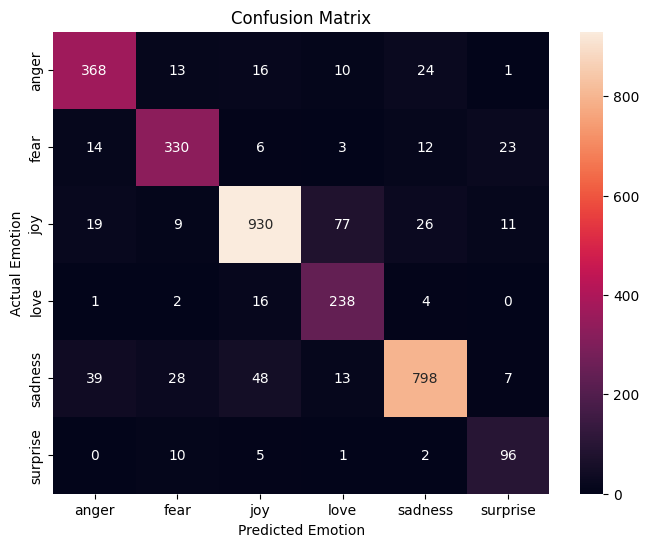

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CREATE MODEL
# ==========================================

model = LogisticRegression(
    max_iter=1000,class_weight='balanced'
)


# ==========================================
# 2. TRAIN MODEL
# ==========================================

model.fit(
    X_train_tfidf,
    y_train
)


# ==========================================
# 3. PREDICT TEST DATA
# ==========================================

y_pred = model.predict(X_test_tfidf)


# ==========================================
# 4. ACCURACY
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# ==========================================
# 5. CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ==========================================
# 6. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Confusion Matrix')

plt.show()

Naive Bayes Accuracy: 0.668125

Naive Bayes Classification Report:
              precision    recall  f1-score   support

       anger       0.96      0.30      0.45       432
        fear       0.90      0.33      0.48       388
         joy       0.60      0.98      0.74      1072
        love       1.00      0.06      0.11       261
     sadness       0.70      0.88      0.78       933
    surprise       1.00      0.01      0.02       114

    accuracy                           0.67      3200
   macro avg       0.86      0.42      0.43      3200
weighted avg       0.76      0.67      0.61      3200



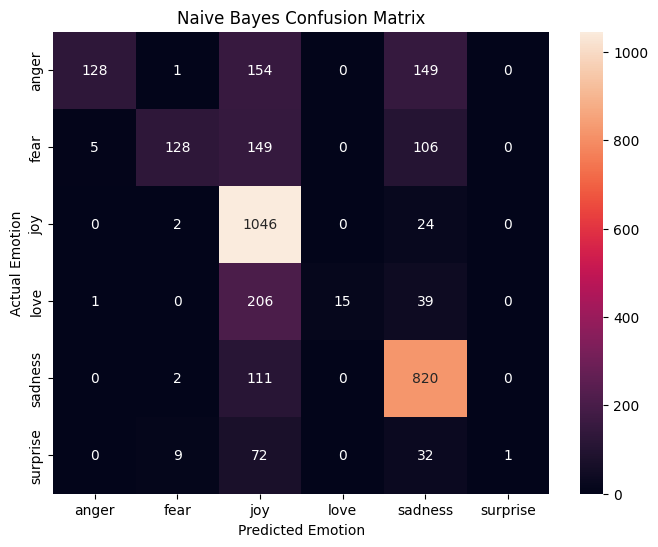

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CREATE MODEL
# ==========================================

nb_model = MultinomialNB()


# ==========================================
# 2. TRAIN
# ==========================================

nb_model.fit(
    X_train_tfidf,
    y_train
)


# ==========================================
# 3. PREDICT
# ==========================================

y_pred_nb = nb_model.predict(X_test_tfidf)


# ==========================================
# 4. ACCURACY
# ==========================================

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)


# ==========================================
# 5. CLASSIFICATION REPORT
# ==========================================

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))


# ==========================================
# 6. CONFUSION MATRIX
# ==========================================

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Naive Bayes Confusion Matrix')

plt.show()

In [25]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(
    class_weight='balanced'
)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.885625

SVM Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.86      0.87       432
        fear       0.85      0.87      0.86       388
         joy       0.91      0.90      0.91      1072
        love       0.75      0.87      0.80       261
     sadness       0.93      0.90      0.92       933
    surprise       0.77      0.82      0.79       114

    accuracy                           0.89      3200
   macro avg       0.85      0.87      0.86      3200
weighted avg       0.89      0.89      0.89      3200



In [26]:
!pip install -q transformers datasets accelerate

import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['emotion'])

print(label_encoder.classes_)

PyTorch: 2.10.0+cu128
Transformers: 5.0.0
GPU available: True
['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


In [27]:
print(df[['text', 'emotion', 'label']].head(10))

                                                text   emotion  label
0                            i didnt feel humiliated   sadness      4
1  i can go from feeling so hopeless to so damned...   sadness      4
2   im grabbing a minute to post i feel greedy wrong     anger      0
3  i am ever feeling nostalgic about the fireplac...      love      3
4                               i am feeling grouchy     anger      0
5  ive been feeling a little burdened lately wasn...   sadness      4
6  ive been taking or milligrams or times recomme...  surprise      5
7  i feel as confused about life as a teenager or...      fear      1
8  i have been with petronas for years i feel tha...       joy      2
9                                i feel romantic too      love      3


In [28]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 12799
Validation: 1600
Test: 1600


In [29]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [30]:
def tokenize_data(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128
    )

In [31]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    'text': list(X_train),
    'label': list(y_train)
})

val_dataset = Dataset.from_dict({
    'text': list(X_val),
    'label': list(y_val)
})

test_dataset = Dataset.from_dict({
    'text': list(X_test),
    'label': list(y_test)
})

In [32]:
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/12799 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [33]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [48]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./emotion_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none"
)

In [35]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_f1 = f1_score(
        labels,
        predictions,
        average='macro'
    )

    weighted_f1 = f1_score(
        labels,
        predictions,
        average='weighted'
    )

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    }

In [36]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [37]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [38]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    'text': list(X_train),
    'label': list(y_train)
})

val_dataset = Dataset.from_dict({
    'text': list(X_val),
    'label': list(y_val)
})

test_dataset = Dataset.from_dict({
    'text': list(X_test),
    'label': list(y_test)
})

In [39]:
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=128
    )

In [50]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/12799 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [49]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [42]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [43]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA version used by PyTorch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))

PyTorch: 2.10.0+cu128
CUDA version used by PyTorch: 12.8
CUDA available: True
GPU: Tesla T4
Compute capability: (7, 5)


In [44]:
!nvidia-smi

Tue Aug 18 16:37:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P0             29W /   70W |     397MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [45]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))

PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4
Compute capability: (7, 5)


In [51]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,No log,0.376564,0.925625,0.884924,0.925217
2,0.325777,0.370630,0.925000,0.882366,0.923554
3,0.212464,0.373337,0.927500,0.889381,0.927977


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1200, training_loss=0.25364588101704916, metrics={'train_runtime': 168.9191, 'train_samples_per_second': 227.31, 'train_steps_per_second': 7.104, 'total_flos': 515794727028708.0, 'train_loss': 0.25364588101704916, 'epoch': 3.0})

In [52]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# Get predictions on the untouched test set
test_results = trainer.predict(test_dataset)

# Convert logits to predicted class
test_predictions = np.argmax(
    test_results.predictions,
    axis=-1
)

# Accuracy
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("Test Accuracy:", test_accuracy)

# Classification report
print("\nTest Classification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_
    )
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test Accuracy: 0.93

Test Classification Report:
              precision    recall  f1-score   support

       anger       0.93      0.93      0.93       216
        fear       0.90      0.90      0.90       194
         joy       0.95      0.93      0.94       536
        love       0.80      0.85      0.83       131
     sadness       0.97      0.97      0.97       466
    surprise       0.82      0.86      0.84        57

    accuracy                           0.93      1600
   macro avg       0.90      0.91      0.90      1600
weighted avg       0.93      0.93      0.93      1600



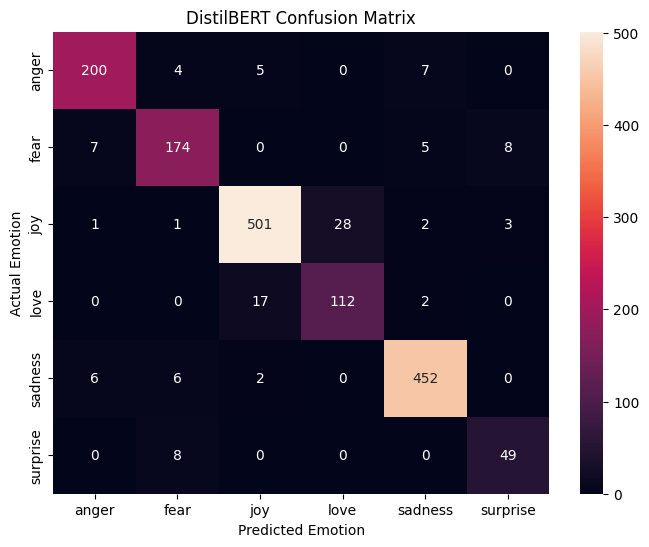

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("DistilBERT Confusion Matrix")

plt.show()